In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray

## Load Edited GeoTIFF

Read the edited bathymetry from the GeoTIFF file.

In [3]:
# Load the edited GeoTIFF
geotiff_path = "bathymetry_final_v2.tif"
h_edited = rioxarray.open_rasterio(geotiff_path, masked=True).isel(x=slice(40, None))

# Remove the band dimension if present
if 'band' in h_edited.dims:
    h_edited = h_edited.squeeze('band', drop=True)

print(f"Loaded bathymetry shape: {h_edited.shape}")
print(f"Depth range: {float(h_edited.min()):.1f} to {float(h_edited.max()):.1f} m")
print(h_edited)

Loaded bathymetry shape: (210, 256)
Depth range: -162.4 to 7.0 m
<xarray.DataArray (y: 210, x: 256)> Size: 430kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(210, 256))
Coordinates:
  * y            (y) float64 2kB 66.18 66.18 66.17 66.17 ... 65.76 65.76 65.76
  * x            (x) float64 2kB -23.32 -23.32 -23.31 ... -22.31 -22.3 -22.3
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


## Extract Coordinates

Extract the latitude and longitude arrays from the GeoTIFF.

In [4]:
# Extract lon and lat from the raster coordinates
lon_1d = h_edited.x.values
lat_1d = h_edited.y.values[::-1]

print(f"Longitude range: {lon_1d.min():.4f} to {lon_1d.max():.4f}")
print(f"Latitude range: {lat_1d.min():.4f} to {lat_1d.max():.4f}")
print(f"Grid size: {len(lat_1d)} x {len(lon_1d)}")

Longitude range: -23.3200 to -22.3000
Latitude range: 65.7600 to 66.1780
Grid size: 210 x 256


In [5]:
h_edited = h_edited.where(h_edited <= -4, 0)

In [6]:
h_edited.max()

<xarray.DataArray ()> Size: 8B
array(0.)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## Visualize Edited Bathymetry

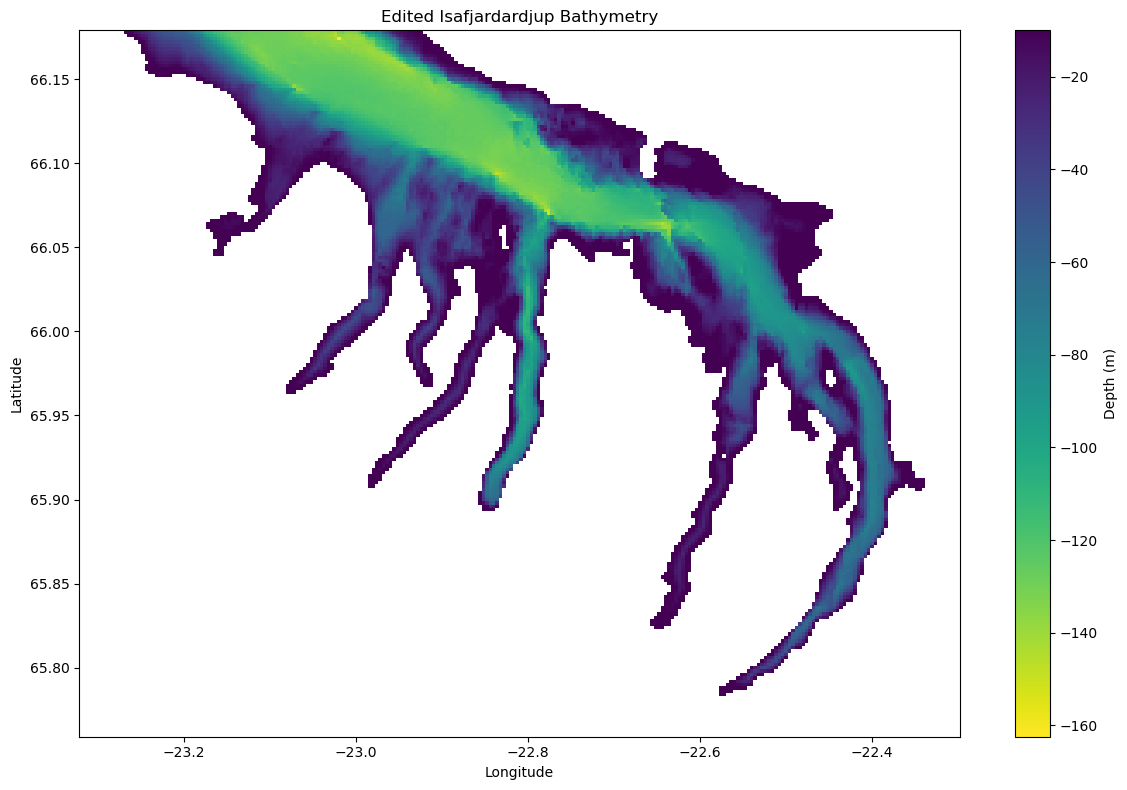

In [7]:
# Plot the edited bathymetry
fig, ax = plt.subplots(figsize=(12, 8))
h_plot = h_edited.where(h_edited != 0)
im = h_plot.plot(ax=ax, cmap='viridis_r', add_colorbar=True, cbar_kwargs={'label': 'Depth (m)'})
ax.set_title('Edited Isafjardardjup Bathymetry')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

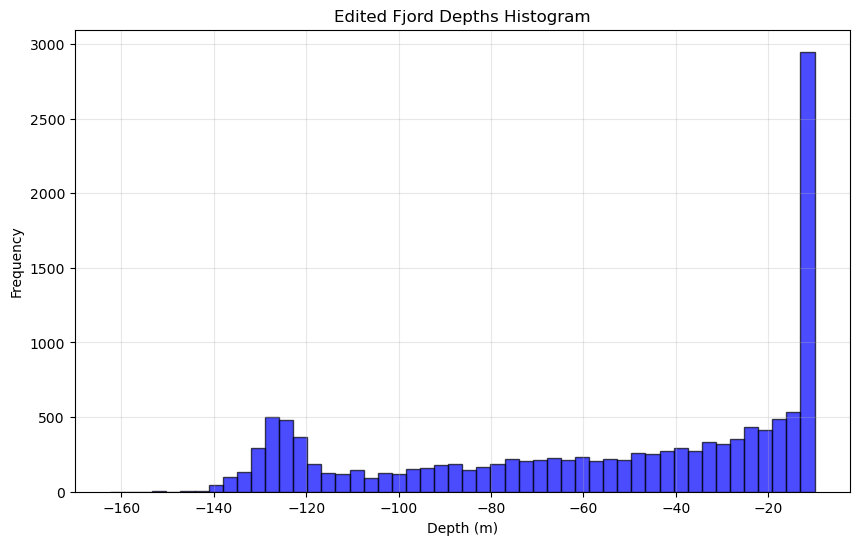

Depth statistics:
  Min: -162.4 m
  Max: -10.0 m
  Mean: -55.0 m
  Median: -42.4 m
  Wet cells: 13124
  Land cells: 40636


In [8]:
# Depth histogram
depth_values = h_edited.values[h_edited.values != 0]
plt.figure(figsize=(10, 6))
plt.hist(depth_values, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Edited Fjord Depths Histogram')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Depth statistics:")
print(f"  Min: {depth_values.min():.1f} m")
print(f"  Max: {depth_values.max():.1f} m")
print(f"  Mean: {depth_values.mean():.1f} m")
print(f"  Median: {np.median(depth_values):.1f} m")
print(f"  Wet cells: {np.sum(h_edited.values != 0)}")
print(f"  Land cells: {np.sum(h_edited.values == 0)}")

## Define Vertical Grid (z_faces)

Use the same vertical grid as the original notebook.

In [9]:
# Define z_faces (same as original notebook)
z_faces = np.array([
    -160.0,
    -150.0,
    -140.0,
    -130.0,
    -120.0,
    -110.0,
    -100.0,
    -90.0,
    -80.0,
    -70.0,
    -60.0,
    -50.0,
    -40.0,
    -30.0,
    -25.0,
    -20.0,
    -18.0,
    -16.0,
    -14.0,
    -12.0,
    -10.0,
    -8.0,
    -6.0,
    -5.0,
    -4.0,
    -3.0,
    -2.0,
    -1.0,
    -0.5,
])

print(f"Number of vertical layers: {len(z_faces) - 1}")
print(f"z_faces range: {z_faces[0]:.1f}m (deepest) to {z_faces[-1]:.1f}m (surface)")

Number of vertical layers: 28
z_faces range: -160.0m (deepest) to -0.5m (surface)


## Create NetCDF File

Create the output NetCDF file with the same structure as the original.

In [10]:
# Convert h_edited to numpy array and transpose if needed to match (y, x) convention
h_values = h_edited.values

# Create xarray Dataset
ds_out = xr.Dataset(
    {
        "h": (["y", "x"], h_values[::-1,:]),
        "z_faces": (["z"], z_faces),
    },
    coords={
        "lat": (["y"], lat_1d),
        "lon": (["x"], lon_1d),
    },
)

# Add attributes
ds_out["h"].attrs = {
    "long_name": "bathymetry depth",
    "units": "meters",
    "positive": "down",
    "description": "Water depth below surface (negative values, 0 for land)"
}

ds_out["z_faces"].attrs = {
    "long_name": "vertical coordinate faces",
    "units": "meters",
    "positive": "up",
    "description": "Vertical layer interfaces: ordered from deepest (most negative) to surface (0)"
}

ds_out["lat"].attrs = {
    "long_name": "latitude",
    "units": "degrees_north"
}

ds_out["lon"].attrs = {
    "long_name": "longitude",
    "units": "degrees_east"
}

ds_out.attrs = {
    "title": "Isafjardardju Bathymetry (Edited) for Oceananigans",
    "created": "2025-11-28",
    "description": "Edited bathymetry data for FjordsSim.jl ImmersedBoundaryGrid function",
    "source": "Edited from GeoTIFF"
}

print(ds_out)

<xarray.Dataset> Size: 434kB
Dimensions:  (y: 210, x: 256, z: 29)
Coordinates:
    lat      (y) float64 2kB 65.76 65.76 65.76 65.77 ... 66.17 66.17 66.18 66.18
    lon      (x) float64 2kB -23.32 -23.32 -23.31 -23.31 ... -22.31 -22.3 -22.3
Dimensions without coordinates: y, x, z
Data variables:
    h        (y, x) float64 430kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    z_faces  (z) float64 232B -160.0 -150.0 -140.0 -130.0 ... -2.0 -1.0 -0.5
Attributes:
    title:        Isafjardardju Bathymetry (Edited) for Oceananigans
    created:      2025-11-28
    description:  Edited bathymetry data for FjordsSim.jl ImmersedBoundaryGri...
    source:       Edited from GeoTIFF


In [11]:
# Save to NetCDF
output_file = "C:/Users/fisa/Documents/Isafjord/input/Isafjord_bathymetry_210x256.nc"
ds_out.to_netcdf(output_file)
print(f"\nEdited bathymetry saved to: {output_file}")


Edited bathymetry saved to: C:/Users/fisa/Documents/Isafjord/input/Isafjord_bathymetry_210x256.nc


In [12]:
ds_out.close()

## Summary

The NetCDF file has been created from the edited GeoTIFF with the following structure:
- **h** (2D): Edited bathymetry depth in meters (negative values for water depth, 0 for land)
- **z_faces** (1D): Vertical coordinate faces (negative values, ordered from deepest to surface: -190m to 0m)
- **lat** (1D): Latitude coordinates (cell centers)
- **lon** (1D): Longitude coordinates (cell centers)

This file can be used with `ImmersedBoundaryGrid(filepath, arch, halo)` in FjordsSim.jl.